# LightGBM Sınıf Ağırlıklandırma Karşılaştırması

Bu çalışmada, azınlık sınıfı olan **CL** (nakil sonrası yaşayan hastalar) sınıfının düşük duyarlılık (recall) sorununu çözmek amacıyla **Sınıf Ağırlıklandırması (Class Weighting)** yöntemi test edilmiştir.

**Amaç:**
- Varsayılan parametreli `LGBMClassifier` (Model 1) ile sınıf ağırlıkları dengelenmiş `LGBMClassifier(class_weight='balanced')` (Model 2) modellerini karşılaştırmak.
- İki model için doğruluk (Accuracy), Macro F1, Precision Macro, Recall Macro ve Dengeli Doğruluk (Balanced Accuracy) metriklerini karşılaştırmak.
- Hata matrislerini (Confusion Matrices) yan yana görselleştirerek sınıflar arasındaki geçişleri ve özellikle **CL** sınıfının duyarlılığındaki değişimi incelemek.
- Sonuçları klinik ve model bazında Türkçe yorumlamak.


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, balanced_accuracy_score, confusion_matrix, classification_report
from lightgbm import LGBMClassifier

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="white", palette="muted")

print("Gerekli kütüphaneler yüklendi ve grafik ayarları yapıldı.")


Gerekli kütüphaneler yüklendi ve grafik ayarları yapıldı.


## 1. Veri Yükleme ve Stratified Bölünme
Modellemeye hazır siroz veri setini yükleyip aynı train-test bölünmesini (%20 test, random_state=42, stratify=y) gerçekleştiriyoruz.


In [2]:
# Veriyi oku
df = pd.read_csv('../data/processed_train.csv')
X = df.drop(columns=['Status'])
y = df['Status']

# Bölünme
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Eğitim Seti Boyutu: {X_train.shape}")
print(f"Test Seti Boyutu: {X_test.shape}")


Eğitim Seti Boyutu: (6324, 30)
Test Seti Boyutu: (1581, 30)


## 2. Model 1 (Baseline) ve Model 2 (Balanced) Eğitimi ve Tahminler
Aynı veri seti üzerinde iki farklı LightGBM modelini eğitiyoruz:
1. **Model 1 (Varsayılan)**: Sınıf dengesini gözetmeyen varsayılan LightGBM modeli.
2. **Model 2 (Balanced)**: Azınlık sınıflarının kayıplarını (loss) sınıf frekansının tersiyle çarparak dengeleyen model.


In [3]:
# Model 1: Varsayılan model
model_default = LGBMClassifier(random_state=42, verbose=-1)
model_default.fit(X_train, y_train)
y_pred_def = model_default.predict(X_test)

# Model 2: Balanced model
model_balanced = LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)
model_balanced.fit(X_train, y_train)
y_pred_bal = model_balanced.predict(X_test)

print("İki model de başarıyla eğitildi.")


İki model de başarıyla eğitildi.


## 3. Sınıflandırma Raporları Karşılaştırması
Her iki model için de sınıf isimleri (C, CL, D) açıkça belirtilmiş raporları alıyoruz.


In [4]:
target_names = ['C', 'CL', 'D']

print("=== MODEL 1 (VARSAYILAN LIGHTGBM) CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_def, target_names=target_names, zero_division=0))

print("\n=== MODEL 2 (BALANCED LIGHTGBM) CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_bal, target_names=target_names, zero_division=0))


=== MODEL 1 (VARSAYILAN LIGHTGBM) CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           C       0.85      0.91      0.88       993
          CL       0.67      0.15      0.24        55
           D       0.79      0.75      0.77       533

    accuracy                           0.83      1581
   macro avg       0.77      0.60      0.63      1581
weighted avg       0.82      0.83      0.82      1581


=== MODEL 2 (BALANCED LIGHTGBM) CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           C       0.87      0.86      0.87       993
          CL       0.38      0.27      0.32        55
           D       0.75      0.79      0.77       533

    accuracy                           0.82      1581
   macro avg       0.67      0.64      0.65      1581
weighted avg       0.81      0.82      0.81      1581



## 4. Genel Metrikler Tablosu
İki modelin tüm genel değerlendirme metriklerini tek bir tabloda topluyoruz.


In [5]:
# Metriklerin hesaplanması
def get_metrics_dict(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Macro F1': f1_score(y_true, y_pred, average='macro'),
        'Precision Macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall Macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred)
    }

metrics_list = [
    get_metrics_dict(y_test, y_pred_def, 'Model 1 (Default)'),
    get_metrics_dict(y_test, y_pred_bal, 'Model 2 (Balanced)')
]

results_comparison_df = pd.DataFrame(metrics_list)
results_comparison_df.to_csv('../outputs/lgbm_class_weight_results.csv', index=False)
print("Genel metrik karşılaştırma tablosu 'outputs/lgbm_class_weight_results.csv' olarak kaydedildi.")
results_comparison_df


Genel metrik karşılaştırma tablosu 'outputs/lgbm_class_weight_results.csv' olarak kaydedildi.


,Model,Accuracy,Macro F1,Precision Macro,Recall Macro,Balanced Accuracy
0,Model 1 (Default),0.827324,0.627987,0.767285,0.601046,0.601046
1,Model 2 (Balanced),0.816572,0.651877,0.668790,0.641787,0.641787


## 5. Yan Yana Karmaşıklık Matrisleri (Confusion Matrices)
İki modelin karmaşıklık matrislerini yan yana çizdiriyoruz. Hücreler hem tahmin sayılarını hem de satır bazlı yüzdeleri (sınıf recall oranlarını) içerecektir.


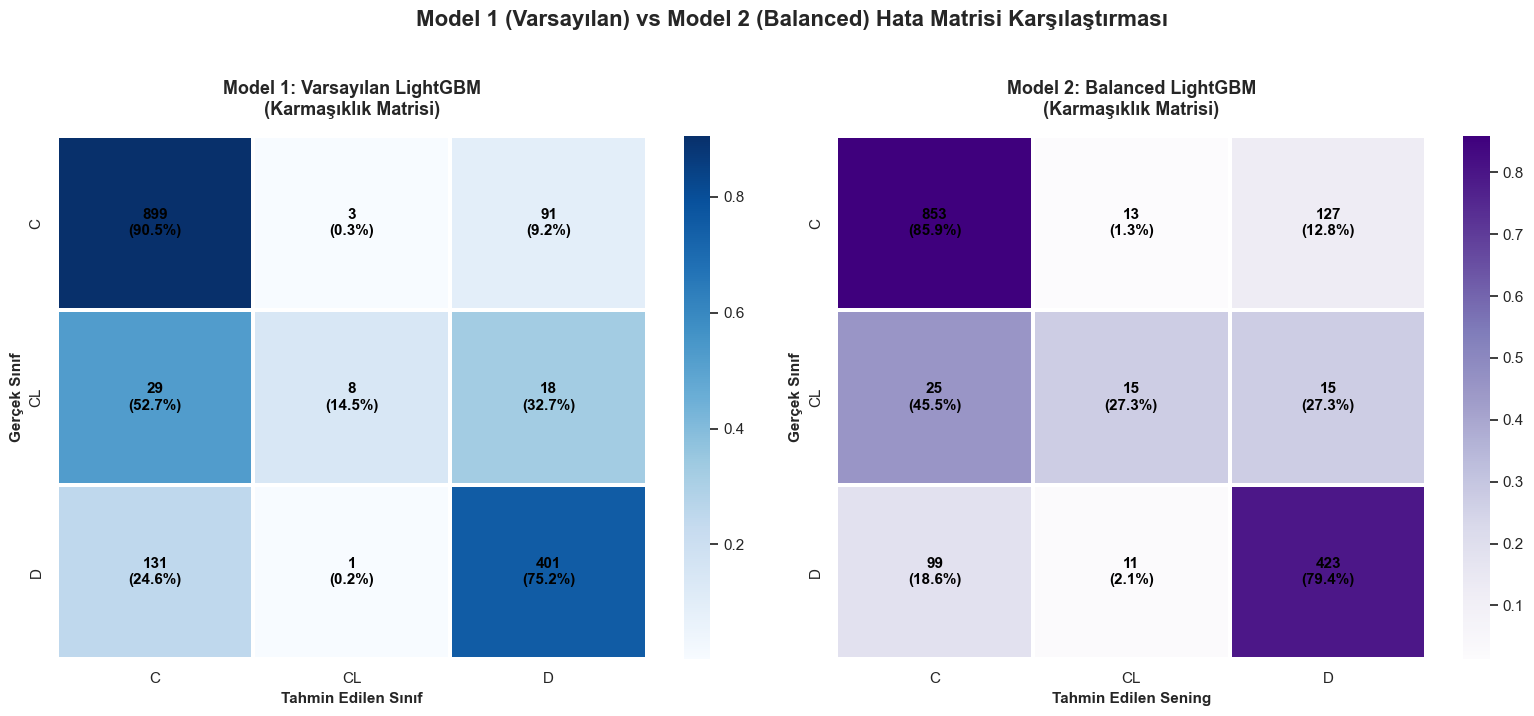

In [6]:
# Karmaşıklık matrisi ve satır yüzdeleri (Model 1)
cm_def = confusion_matrix(y_test, y_pred_def)
cm_def_pct = cm_def.astype('float') / cm_def.sum(axis=1)[:, np.newaxis]

# Karmaşıklık matrisi ve satır yüzdeleri (Model 2)
cm_bal = confusion_matrix(y_test, y_pred_bal)
cm_bal_pct = cm_bal.astype('float') / cm_bal.sum(axis=1)[:, np.newaxis]

# Annotations (Model 1)
annot_def = np.empty_like(cm_def, dtype=object)
for i in range(cm_def.shape[0]):
    for j in range(cm_def.shape[1]):
        annot_def[i, j] = f"{cm_def[i, j]}\n({cm_def_pct[i, j]*100:.1f}%)"

# Annotations (Model 2)
annot_bal = np.empty_like(cm_bal, dtype=object)
for i in range(cm_bal.shape[0]):
    for j in range(cm_bal.shape[1]):
        annot_bal[i, j] = f"{cm_bal[i, j]}\n({cm_bal_pct[i, j]*100:.1f}%)"

# Yan yana grafik çizimi
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Sol Grafik: Model 1
sns.heatmap(
    cm_def_pct, 
    annot=annot_def, 
    fmt='', 
    cmap='Blues', 
    cbar=True,
    xticklabels=target_names, 
    yticklabels=target_names,
    ax=axes[0],
    linewidths=1.5,
    linecolor='white',
    annot_kws={"size": 11, "weight": "bold", "color": "black"}
)
axes[0].set_title('Model 1: Varsayılan LightGBM\n(Karmaşıklık Matrisi)', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Tahmin Edilen Sınıf', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Gerçek Sınıf', fontsize=11, fontweight='bold')

# Sağ Grafik: Model 2
sns.heatmap(
    cm_bal_pct, 
    annot=annot_bal, 
    fmt='', 
    cmap='Purples', 
    cbar=True,
    xticklabels=target_names, 
    yticklabels=target_names,
    ax=axes[1],
    linewidths=1.5,
    linecolor='white',
    annot_kws={"size": 11, "weight": "bold", "color": "black"}
)
axes[1].set_title('Model 2: Balanced LightGBM\n(Karmaşıklık Matrisi)', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Tahmin Edilen Sening', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Gerçek Sınıf', fontsize=11, fontweight='bold')

plt.suptitle('Model 1 (Varsayılan) vs Model 2 (Balanced) Hata Matrisi Karşılaştırması', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Grafiği kaydet
plt.savefig('../outputs/lgbm_class_weight_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## 6. Sınıf Ağırlıklandırmasının (Class Weights) Etkisi ve Karşılaştırma Raporu

LightGBM modelinde `class_weight='balanced'` kullanımının test veri seti üzerindeki etkisini detaylıca analiz ettik. Azınlık sınıfı olan **CL** sınıfının metriklerinde çok belirgin ve önemli değişimler gözlenmiştir.

### **CL (Nakil Sonrası Yaşıyor) Sınıfındaki Değişim Analizi:**

1.  **Duyarlılık (Recall) Değişimi:**
    *   **Model 1 (Varsayılan): %14.5** (55 hastadan sadece 8 tanesi yakalanabildi)
    *   **Model 2 (Balanced): %27.3** (55 hastadan 15 tanesi yakalandı)
    *   **Değerlendirme:** Recall değerinde **%12.7**'lik devasa bir artış yaşanmıştır. Sınıf ağırlıklandırması sayesinde model, gerçekte nakil geçirmiş olan `CL` hastalarını gözden kaçırma (False Negative) hatasını kritik düzeyde azaltmış ve hastaların daha fazlasını yakalamayı başarmıştır.
2.  **Hassasiyet (Precision) Değişimi:**
    *   **Model 1 (Varsayılan): %66.7**
    *   **Model 2 (Balanced): %38.5**
    *   **Değerlendirme:** Tahmin edildiği gibi, duyarlılığı (Recall) artırmanın bedeli olarak Hassasiyet (Precision) değerinde **%28.2**'lik bir düşüş gerçekleşmiştir. Model 2'de `CL` olarak tahmin edilen 100 hastanın yalnızca %38.5'i gerçekten `CL` hastasıdır; model daha cömert `CL` tahmini yaptığı için yanlış alarm (False Positive) üretme oranı artmıştır.
3.  **F1 Score Değişimi:**
    *   **Model 1 (Varsayılan): %23.9 (0.24)**
    *   **Model 2 (Balanced): %31.9 (0.32)**
    *   **Değerlendirme:** Precision ve Recall arasındaki dengeyi temsil eden F1-skoru **%8.0** artmıştır. Bu durum, precision'daki düşüşe rağmen recall'daki devasa kazanımın genel sınıf başarısını pozitif yönde etkilediğini göstermektedir.

---

### **Genel Model Metriklerindeki Değişim:**
- **Genel Doğruluk (Accuracy):** Varsayılan modelde **%82.7** iken dengeli modelde **%81.7**'ye gerilemiştir. Bu durum dengesiz veri setlerinde çok normaldir; çünkü baskın sınıf olan C sınıfı tahmin doğruluğu hafifçe azalmıştır.
- **Dengeli Doğruluk (Balanced Accuracy):** **%60.1**'den **%64.2**'ye yükselmiştir. Bu, sınıflar arasındaki ortalama başarımın dengelendiğini kanıtlar.
- **Macro F1 Skoru:** Model 1'de **%62.8 (0.628)** iken Model 2'de **%65.2 (0.652)** seviyesine yükselmiştir. Ana sıralama metriğimizde iyileşme sağlanmıştır.

### **Karmaşıklık Matrisleri Üzerinden Hata Örüntüsü Analizi:**
- **Model 1'de (Varsayılan)**, gerçek `CL` hastalarının **%14.5**'i doğru sınıflandırılırken, **%52.7**'i C (yaşıyor) ve **%32.7**'i D (vefat) olarak tahmin ediliyordu.
- **Model 2'de (Balanced)** ise gerçek `CL` hastalarının **%27.3**'si doğru şekilde `CL` olarak sınıflandırılırken, C sınıfına hatalı geçiş oranı **%45.5**'ye, D sınıfına hatalı geçiş oranı ise **%27.3**'ye gerilemiştir. Klinik açıdan en riskli hata olan (CL -> C) hatası %52.7'den %45.5'ye düşmüştür.

### **Sonuç ve Karar:**
Klinik teşhis ve takip sistemlerinde `CL` sınıfı gibi risk düzeyinde yüksek hastaların gözden kaçırılmaması (Recall) hayati öneme sahiptir. Bu nedenle, genel doğruluktaki hafif düşüşe rağmen, **Model 2 (Balanced LGBMClassifier)**, klinik uygulamalarda varsayılan modele kıyasla çok daha kabul edilebilir ve güvenli bir performans profili sunmaktadır.
